In [16]:
%load_ext autoreload
%autoreload 2

import featuregraph as fg

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
subject_id = 13
sampling_rate_hz = 125
smooth_window = 100
eps = 1e-12

df = fg.datasets.bidmc(subject=subject_id).copy()

# Construct the respiratory envelope.
df['respiration_smooth'] = (
    df['respiration']
    .rolling(smooth_window, min_periods=smooth_window)
    .max()
    .rolling(smooth_window, min_periods=smooth_window)
    .mean()
    .shift(-smooth_window)
)

# Preserve the signed change.
df['respiration_change'] = (
    df['respiration_smooth'].diff()
)

# A sample is valid for state assignment only when both the envelope
# and its preceding difference are defined.
df['respiration_smooth_valid'] = (
    df['respiration_smooth'].notna()
    & df['respiration_change'].notna()
)

valid = df['respiration_smooth_valid']

# Mutually exclusive directional states.
df['respiration_rising'] = (
    valid
    & df['respiration_change'].gt(eps)
)

df['respiration_falling'] = (
    valid
    & df['respiration_change'].lt(-eps)
)

df['respiration_inactive'] = (
    valid
    & df['respiration_change'].abs().le(eps)
)

# Initialize events as False everywhere, including invalid edge samples.
df['enter_respiration_rising'] = False
df['exit_respiration_rising'] = False

# Calculate events only within the valid constructed interval.
df.loc[valid, 'enter_respiration_rising'] = (
    df.loc[valid, 'respiration_rising']
    .astype(int)
    .diff()
    .eq(1)
)

df.loc[valid, 'exit_respiration_rising'] = (
    df.loc[valid, 'respiration_rising']
    .astype(int)
    .diff()
    .eq(-1)
)

# Assign identity only after the final event columns have been constructed.
df['exit_respiration_rising_id'] = (
    df['exit_respiration_rising']
    .astype(int)
    .cumsum()
)

# Validate state exclusivity and completeness.
state_columns = [
    'respiration_rising',
    'respiration_falling',
    'respiration_inactive',
]

state_count = df[state_columns].sum(axis=1)

assert state_count[valid].eq(1).all()

In [18]:
summarydf = df.groupby('exit_respiration_rising_id').agg(
    respiration_rising_samples=('respiration_rising', 'sum'),
    respiration_falling_samples=('respiration_falling', 'sum'),
    respiration_inactive_samples=('respiration_inactive', 'sum'),
    enter_rising_count=('enter_respiration_rising', 'sum'),
    exit_rising_count=('exit_respiration_rising', 'sum'),
    start_index=('time', 'first'),
    end_index=('time', 'last'),
)

In [19]:
summarydf

,respiration_rising_samples,respiration_falling_samples,respiration_inactive_samples,enter_rising_count,exit_rising_count,start_index,end_index
exit_respiration_rising_id,,,,,,,
0,65,0,0,0,0,0.000,1.304
1,139,199,4,1,1,1.312,4.040
2,123,217,2,1,1,4.048,6.776
3,167,271,3,1,1,6.784,10.304
4,121,219,1,1,1,10.312,13.032
...,...,...,...,...,...,...,...
220,114,215,8,1,1,469.760,472.450
221,228,220,1,1,1,472.460,476.040
222,114,117,2,1,1,476.050,477.900


(<Figure size 1600x1760 with 8 Axes>,
 array([<Axes: ylabel='respiration'>, <Axes: ylabel='respiration_smooth'>,
        <Axes: ylabel='respiration_rising'>,
        <Axes: ylabel='respiration_falling'>,
        <Axes: ylabel='respiration_inactive'>,
        <Axes: ylabel='enter_respiration_rising'>,
        <Axes: ylabel='exit_respiration_rising'>,
        <Axes: xlabel='Time', ylabel='exit_respiration_rising_id'>],
       dtype=object))

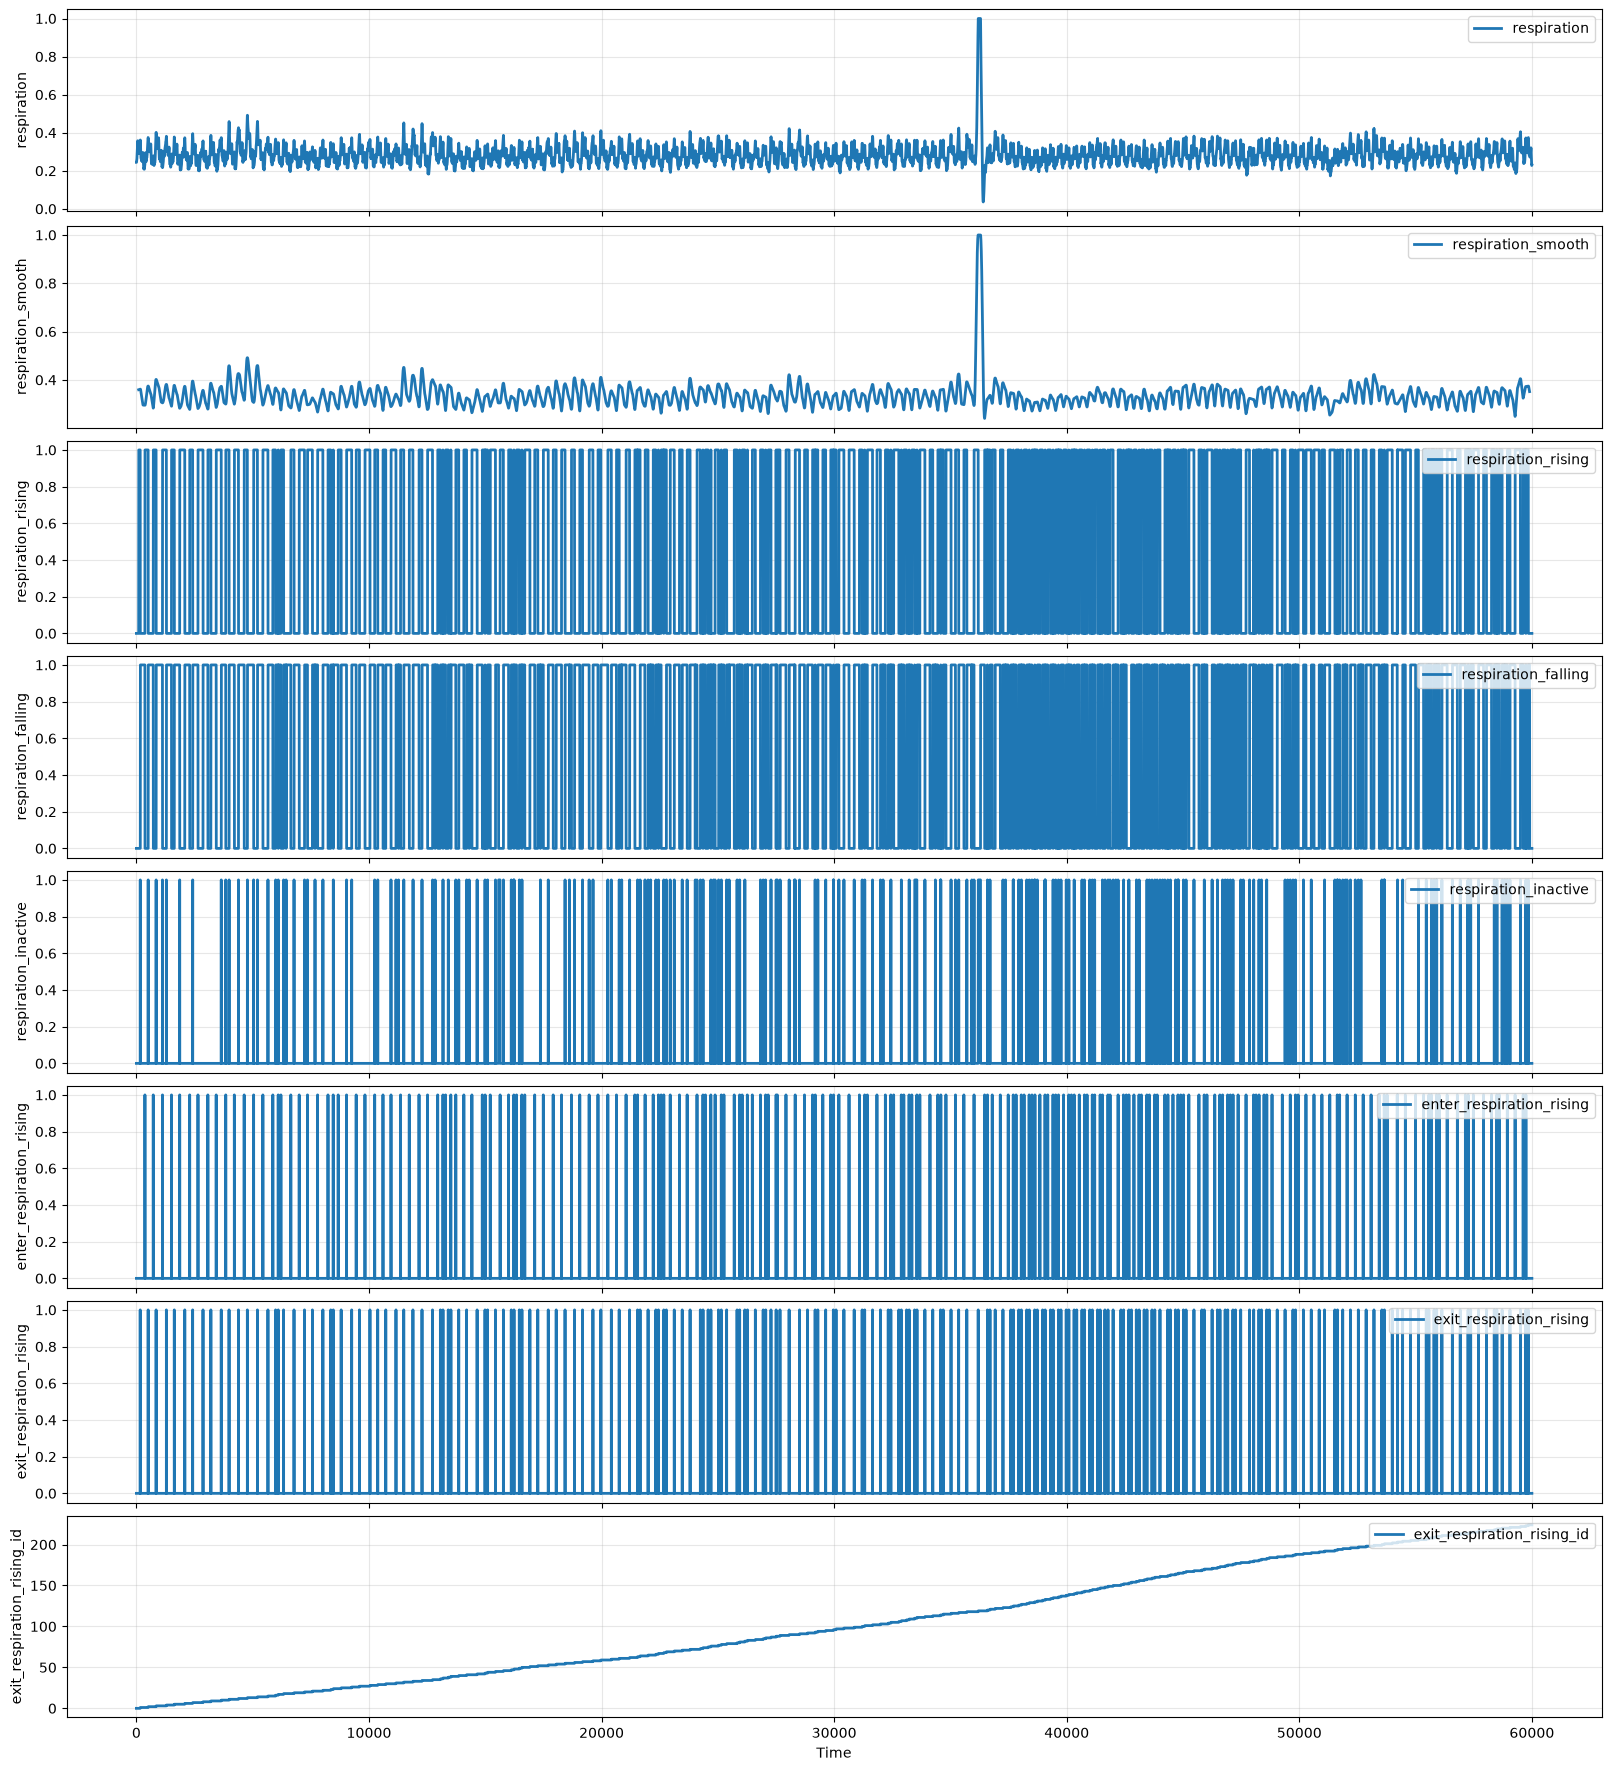

In [20]:
fg.plot(df, [['respiration'],
                              ['respiration_smooth'],
                              ['respiration_rising'],
                              ['respiration_falling'],
                              ['respiration_inactive'],
                              ['enter_respiration_rising'],
                              ['exit_respiration_rising'],
                              ['exit_respiration_rising_id']
                             ]
)